In [1]:
import os
import glob
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [2]:
def setup_data_and_fonts(setup=False):
    if setup:
      ! sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended texlive-science
      ! wget https://github.com/radical-experiments/impress-experiments/raw/refs/heads/main/plots/fonts/nimbus_roman_becker_no9l.ttf
      ! mv nimbus_roman_becker_no9l.ttf sample_data/fonts/nimbus_roman_becker_no9l.ttf
      ! rm ~/.cache/matplotlib -rf

    fonts_dir = os.path.join(os.getcwd(), 'sample_data/fonts')
    # see: https://github.com/radical-cybertools/tutorials/tree/main/src/devel

    if os.path.isdir(fonts_dir):
        try:
            fm.fontManager.addfont(fm.findSystemFonts(fonts_dir)[0])
            mpl.rcParams['text.usetex'] = False
            mpl.rcParams['font.serif']  = ['Nimbus Roman Becker No9L']
            mpl.rcParams['font.family'] = 'serif'
        except Exception as e:
            print(f'WARNING: font is not set ({e})')
    else:
        print('WARNING: directory with font(s) not found')

    if not os.path.isdir('sample_data/resource_files_maxwell'):
        ! wget https://github.com/radical-experiments/impress-experiments/raw/refs/heads/feature/non-rp-utilization/data/amarel/control_resources_maxwell.zip
        ! mv control_resources_maxwell.zip sample_data/
        ! unzip sample_data/control_resources_maxwell.zip sample_data
    else:
        print('Data folder is found')

In [3]:
def load_logs_to_df():
  log_files = glob.glob("sample_data/resource_files_maxwell/*.log")  # Adjust path if necessary
  dfs = []

  for file in log_files:
      df = pd.read_csv(file)

      # Convert timestamp
      df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

      # Clean and convert columns
      df["CPU Usage"] = pd.to_numeric(df["CPU Usage"].astype(str).str.rstrip("%"), errors="coerce")
      df["GPU Usage"] = pd.to_numeric(df["GPU Usage"].astype(str).str.rstrip("%,"), errors="coerce")
      df["GPU Memory Usage"] = pd.to_numeric(df["GPU Memory Usage"].astype(str).str.replace(" MB", ""), errors="coerce")

      dfs.append(df)

  # Combine all data and sort
  combined_df = pd.concat(dfs).sort_values(by="Timestamp").reset_index(drop=True)

  print(f'CPU average utilization: {combined_df["CPU Usage"].mean()}')
  print(f'GPU average utilization: {combined_df["GPU Usage"].mean()}')

  return combined_df

In [4]:
def plot_and_save(combined_df, save=True):

  # Remove idle periods where both CPU and GPU usage are NaN or zero
  active_df = combined_df.dropna(subset=["CPU Usage", "GPU Memory Usage", "GPU Usage"], how="all")
  active_df = active_df[(active_df["CPU Usage"] > 0) | (active_df["GPU Memory Usage"] > 0) | (active_df["GPU Usage"] > 0)]

  # Create a new continuous index as time (removing idle gaps)
  active_df["Time (s)"] = (active_df["Timestamp"] - active_df["Timestamp"].min()).dt.total_seconds()
  active_df["Time Index"] = range(len(active_df))  # Sequential time index

  # Increase figure size
  fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)  # Bigger figure

  bar_width = 1900  # Keep thick bars

  # **CPU Usage Plot (With Idle Background)**
  axs[0].bar(active_df["Time Index"], 100, color="#f0f0f0", width=bar_width, label="Idle", align='edge')  # Idle background
  axs[0].bar(active_df["Time Index"], active_df["CPU Usage"], color="#88bb88", width=bar_width, label="Running", align='edge')

  axs[0].set_ylabel("CPU (%)", fontsize=18)  # Bigger y-label
  axs[0].legend(fontsize=18, loc='upper center', ncol=2)  # Bigger legend
  axs[0].tick_params(axis='both', labelsize=14)  # Bigger tick labels

  # **GPU Usage Plot (With Idle Background)**
  axs[1].bar(active_df["Time Index"], 100, color="#f0f0f0", width=bar_width, label="Idle", align='edge')  # Idle background
  axs[1].bar(active_df["Time Index"], active_df["GPU Usage"], color="#88bb88", width=bar_width, label="Running", align='edge')

  axs[1].set_ylabel("GPU (%)", fontsize=18)
  axs[1].set_xlabel("Time (s)", fontsize=18)  # Adjusted X-axis label
  axs[1].tick_params(axis='both', labelsize=14)

  plt.tight_layout()
  plt.show()

  if save:
    fig.savefig('sample_data/control_impress.pdf')

Data folder is found
CPU average utilization: 7.271976592309197
GPU average utilization: 0.005985622165314245


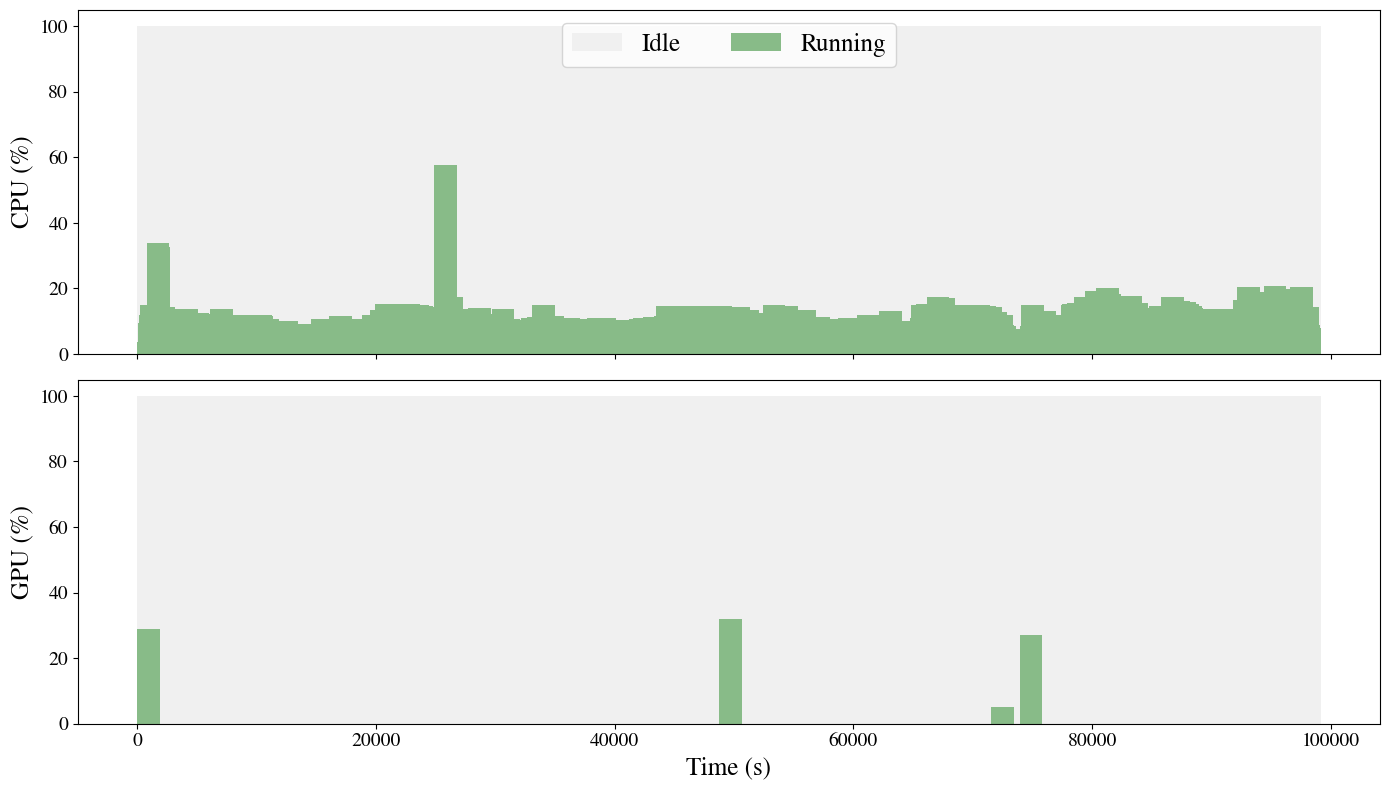

In [5]:
setup_data_and_fonts()
df = load_logs_to_df()
plot_and_save(df, save=True)